# Giới thiệu các phương pháp:

Trong phần này, chúng ta sẽ đánh giá hiệu suất của 4 phương pháp giải hệ phương trình tuyến tính $Ax=b$ trên ma trận ngẫu nhiên và ma trận Hilbert. Các phương pháp bao gồm:

1. **Khử Gauss (Gaussian Elimination)**: Phương pháp cổ điển, có độ phức tạp $O(n^3)$, nhưng thường cho kết quả chính xác cao trên ma trận ngẫu nhiên.

2. **Cholesky**: Phương pháp hiệu quả cho ma trận đối xứng dương (SPD), với độ phức tạp $O(n^3/3)$. Tuy nhiên, nó có thể gặp khó khăn về độ ổn định trên ma trận Hilbert khi kích thước tăng.

3. **Gauss-Seidel**: Phương pháp lặp, có độ phức tạp $O(n^3)$ trong trường hợp xấu nhất, nhưng thường nhanh hơn trên ma trận thưa và có thể ổn định trên ma trận Hilbert.

4. **Hệ PT Chuẩn**: Phương pháp bình phương tối thiểu bằng cách chuẩn hóa ma trận thông qua đặt $P = A^T A$ và $c = A^T b$. Từ đó ma trận $P$ sẽ là ma trận đối xứng dương, cho phép sử dụng Cholesky. Tuy nhiên, phương pháp này có thể làm tăng độ lệch số học và giảm độ chính xác, đặc biệt trên ma trận Hilbert, độ phức tạp là $O(n^3 / 3 + n^2)$.


# **Kết quả thực nghiệm với ma trận ngẫu nhiên kích thước n = [50, 100, 200, 500, 1000]**

========== BENCHMARK RANDOM ==========
Ma tran su dung trong benchmark nay la ma tran ngau nhien thuong (khong rang buoc SPD).
Sai so tuong doi: ||A x_hat - b||_2 / ||b||_2

[========== n = 50 ==========]
 - Khử Gauss                :   0.0032s | Sai so: 3.29e-16 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :   0.0090s | Sai so: 2.82e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.0007s | Sai so: 1.95e-09 | Thanh cong: 5/5

[========== n = 100 ==========]
 - Khử Gauss                :   0.0202s | Sai so: 4.83e-16 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :   0.0732s | Sai so: 4.03e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.0027s | Sai so: 1.52e-09 | Thanh cong: 5/5

[========== n = 200 ==========]
 - Khử Gauss                :   0.1777s | Sai so: 7.18e-16 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :   0.5643s | Sai so: 4.79e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.0092s | Sai so: 3.82e-09 | Thanh cong: 5/5

[========== n = 500 ==========]
 - Khử Gauss                :   2.9023s | Sai so: 1.14e-15 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :   9.1724s | Sai so: 6.91e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.0608s | Sai so: 1.07e-08 | Thanh cong: 5/5

[========== n = 1000 ==========]
 - Khử Gauss                :  23.4276s | Sai so: 1.61e-15 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :  82.0891s | Sai so: 9.79e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.2480s | Sai so: 2.62e-09 | Thanh cong: 5/5

# **Nhận xét:**

## **1. Hiệu năng**

- Thời gian của Khử Gauss tăng mạnh theo kích thước bài toán: từ 0.0032s (n=50) lên 23.4276s (n=1000), phù hợp xu hướng tăng nhanh của nhóm thuật toán khử trực tiếp.

- Hệ PT Chuẩn (Cholesky) là phương pháp chậm nhất ở n lớn: 82.0891s tại n=1000, chậm hơn rõ rệt so với Khử Gauss do phải tạo và giải hệ trên ma trận biến đổi. 

- Lặp Gauss-Seidel có thời gian nhanh nhất trong các phương pháp thành công ở mọi n (0.2480s tại n=1000), cho thấy lợi thế về tốc độ trong bộ dữ liệu hiện tại.

- Phân rã Cholesky thất bại 100% trên bộ ma trận ngẫu nhiên này (0/5 ở mọi n) với lỗi matrix must be symmetric, phù hợp điều kiện áp dụng của Cholesky.

## **2. Độ chính xác**

- Khử Gauss và Hệ PT Chuẩn cho sai số rất nhỏ, cỡ 10^-16 đến 10^-15.

- Gauss-Seidel có sai số lớn hơn, cỡ 10^-9 đến 10^-8, vẫn chấp nhận được cho nhiều bài toán thực hành nhưng kém chính xác hơn các phương pháp trực tiếp.


# **Biểu đồ so sánh thời gian chạy (log-log)**

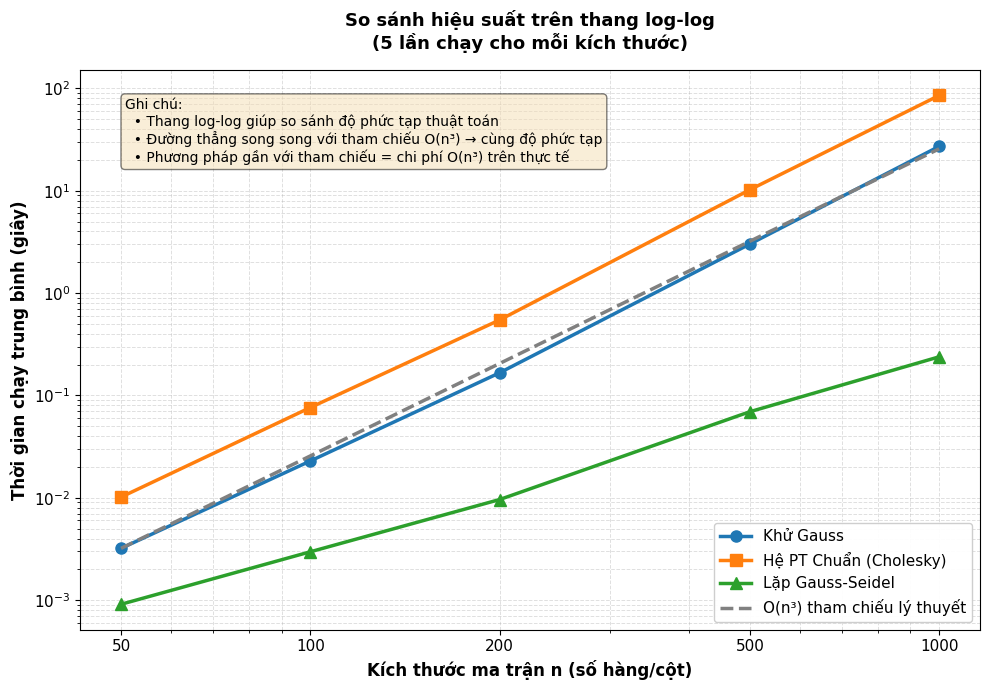

In [3]:
from benchmark import run_benchmark
import matplotlib.pyplot as plt

# Lấy số liệu trực tiếp từ hàm benchmark, không dùng numpy và không nhập tay mảng số
results = run_benchmark(verbose=False)

# Trích xuất các giá trị n và thời gian chạy cho từng phương pháp
n_values = sorted(results['Khu Gauss'].keys())
gauss_times = [results['Khu Gauss'][n]['avg_time'] for n in n_values]
cholesky_eq_times = [results['He PT Chuan (Cholesky)'][n]['avg_time'] for n in n_values]
gauss_seidel_times = [results['Lap Gauss-Seidel'][n]['avg_time'] for n in n_values]

# Đường tham chiếu O(n^3): chuẩn hóa theo điểm đầu của Khử Gauss
# Công thức: T(n) = T(n₀) × (n/n₀)³, với n₀ = 50
ref_on3 = [gauss_times[0] * (n / n_values[0]) ** 3 for n in n_values]

# ===== Vẽ biểu đồ log-log =====
plt.figure(figsize=(10, 7))

# Plot các đường cho từng phương pháp
plt.loglog(n_values, gauss_times, marker='o', markersize=8, linewidth=2.5, label='Khử Gauss')
plt.loglog(n_values, cholesky_eq_times, marker='s', markersize=8, linewidth=2.5, label='Hệ PT Chuẩn (Cholesky)')
plt.loglog(n_values, gauss_seidel_times, marker='^', markersize=8, linewidth=2.5, label='Lặp Gauss-Seidel')
plt.loglog(n_values, ref_on3, linestyle='--', linewidth=2.5, color='gray', label='O(n³) tham chiếu lý thuyết')

# Thiết lập tất cả các giá trị n trên trục x
plt.xticks(n_values, [str(n) for n in n_values], fontsize=11)
plt.yticks(fontsize=11)

# ===== Nhãn và tiêu đề =====
plt.xlabel('Kích thước ma trận n (số hàng/cột)', fontsize=12, fontweight='bold')
plt.ylabel('Thời gian chạy trung bình (giây)', fontsize=12, fontweight='bold')
plt.title('So sánh hiệu suất trên thang log-log\n(5 lần chạy cho mỗi kích thước)', 
          fontsize=13, fontweight='bold', pad=15)

# ===== Grid và legend =====
plt.grid(True, which='both', linestyle='--', alpha=0.4, linewidth=0.7)
plt.legend(fontsize=11, loc='best', framealpha=0.95)

# ===== Chú thích chi tiết =====
# Chú thích cho đường tham chiếu
plt.text(0.05, 0.95, 
         'Ghi chú:\n' +
         '  • Thang log-log giúp so sánh độ phức tạp thuật toán\n' +
         '  • Đường thẳng song song với tham chiếu O(n³) → cùng độ phức tạp\n' +
         '  • Phương pháp gần với tham chiếu = chi phí O(n³) trên thực tế',
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


## **Biểu đồ sai số trên ma trận ngẫu nhiên**
Biểu đồ dưới đây dùng cùng bộ dữ liệu benchmark ở Part 3 để so sánh sai số tương đối theo kích thước ma trận.

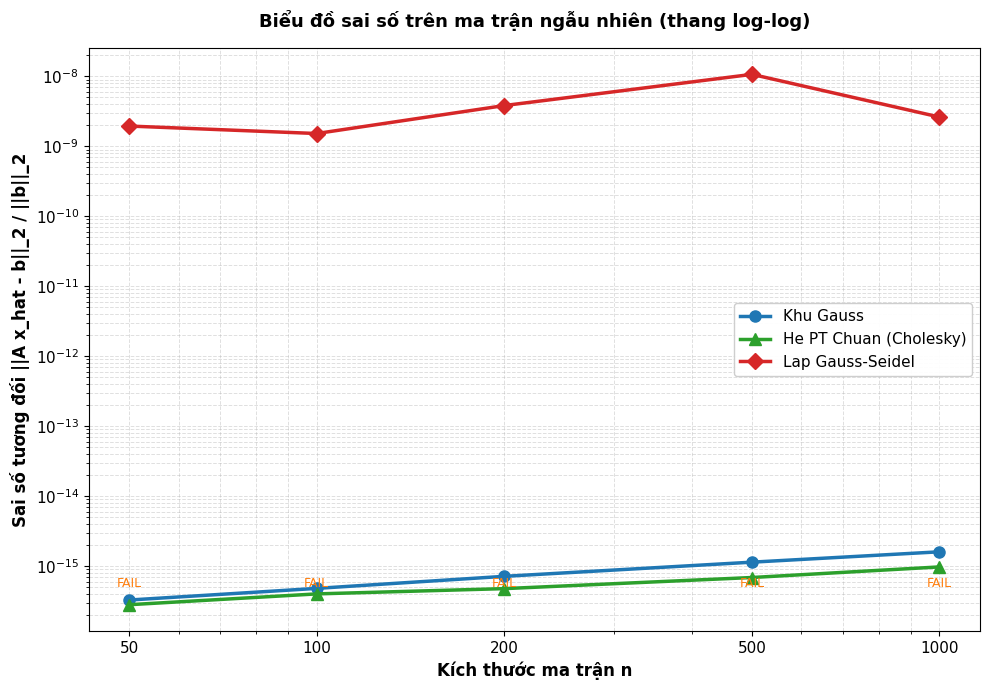

In [2]:
from benchmark import run_benchmark
import matplotlib.pyplot as plt

# Dữ liệu benchmark ma trận ngẫu nhiên (5 lần chạy cho mỗi n)
results_random = run_benchmark(verbose=False)

# Trích xuất các giá trị n và thời gian chạy cho từng phương pháp
n_values = sorted(results_random['Khu Gauss'].keys())
methods = ['Khu Gauss', 'Phan ra Cholesky', 'He PT Chuan (Cholesky)', 'Lap Gauss-Seidel']
style_map = {
    'Khu Gauss': ('o', '#1f77b4'),
    'Phan ra Cholesky': ('s', '#ff7f0e'),
    'He PT Chuan (Cholesky)': ('^', '#2ca02c'),
    'Lap Gauss-Seidel': ('D', '#d62728'),
}

plt.figure(figsize=(10, 7))

for method in methods:
    y_vals = []
    x_vals = []
    for n in n_values:
        err = results_random[method][n]['avg_error']
        if err is not None and err > 0:
            x_vals.append(n)
            y_vals.append(err)

    marker, color = style_map[method]
    if x_vals:
        plt.loglog(x_vals, y_vals, marker=marker, markersize=8, linewidth=2.5, color=color, label=method)

# Đánh dấu rõ các phương pháp thất bại ở n tương ứng (ví dụ Cholesky trên ma trận ngẫu nhiên thường)
fail_ns = [n for n in n_values if results_random['Phan ra Cholesky'][n]['avg_error'] is None]
if fail_ns:
    y_mark = min(
        results_random['Khu Gauss'][n]['avg_error']
        for n in n_values
        if results_random['Khu Gauss'][n]['avg_error'] is not None
    )
    for n in fail_ns:
        plt.text(n, y_mark * 1.4, 'FAIL', color='#ff7f0e', ha='center', va='bottom', fontsize=9)

plt.xticks(n_values, [str(n) for n in n_values], fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Kích thước ma trận n', fontsize=12, fontweight='bold')
plt.ylabel('Sai số tương đối', fontsize=12, fontweight='bold')
plt.title('Biểu đồ sai số trên ma trận ngẫu nhiên (thang log-log)', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, which='both', linestyle='--', alpha=0.4, linewidth=0.7)
plt.legend(fontsize=11, loc='best', framealpha=0.95)
plt.tight_layout()
plt.show()


# **Kết quả phân tích ổn định 2 loại ma trận: SPD và Hilbert**

========== BENCHMARK TINH ON DINH SO ==========
Muc tieu: So sanh do chinh xac tren ma tran Tot (SPD) va ma tran Xau (Hilbert).     
Kich thuoc thu nghiem: n = 10. So lan chay: 5
Sai so tuong doi: ||A x_hat - b||_2 / ||b||_2

[========== Ma tran: SPD (Well-conditioned) ==========]
 - Khu Gauss                :   0.0001s | Sai so: 9.18e-17 | Thanh cong: 5/5        
 - Phan ra Cholesky         :   0.0001s | Sai so: 7.26e-17 | Thanh cong: 5/5        
 - He PT Chuan (Cholesky)   :   0.0001s | Sai so: 4.65e-16 | Thanh cong: 5/5        
 - Lap Gauss-Seidel         :   0.0001s | Sai so: 8.21e-10 | Thanh cong: 5/5        

[========== Ma tran: Hilbert (Ill-conditioned) ==========]
 - Khu Gauss                : THAT BAI (0/5). Vi du loi: he khong co nghiem duy nhat
 - Phan ra Cholesky         :   0.0001s | Sai so: 8.50e-17 | Thanh cong: 5/5        
 - He PT Chuan (Cholesky)   : THAT BAI (0/5). Vi du loi: Ma tran khong xac dinh duong.
 - Lap Gauss-Seidel         :   0.0033s | Sai so: 8.35e-06 | Thanh cong: 5/5


========== BENCHMARK TINH ON DINH SO ==========
Muc tieu: So sanh do chinh xac tren ma tran Tot (SPD) va ma tran Xau (Hilbert).
Kich thuoc thu nghiem: n = 20. So lan chay: 5
Sai so tuong doi: ||A x_hat - b||_2 / ||b||_2

[========== Ma tran: SPD (Well-conditioned) ==========]
 - Khu Gauss                :   0.0006s | Sai so: 9.39e-17 | Thanh cong: 5/5
 - Phan ra Cholesky         :   0.0004s | Sai so: 1.38e-16 | Thanh cong: 5/5
 - He PT Chuan (Cholesky)   :   0.0012s | Sai so: 5.83e-16 | Thanh cong: 5/5
 - Lap Gauss-Seidel         :   0.0010s | Sai so: 9.55e-10 | Thanh cong: 5/5

[========== Ma tran: Hilbert (Ill-conditioned) ==========]
 - Khu Gauss                : THAT BAI (0/5). Vi du loi: he khong co nghiem duy nhat
 - Phan ra Cholesky         : THAT BAI (0/5). Vi du loi: Ma tran khong xac dinh duong.
 - He PT Chuan (Cholesky)   : THAT BAI (0/5). Vi du loi: Ma tran khong xac dinh duong.
 - Lap Gauss-Seidel         :   0.0134s | Sai so: 1.71e-05 | Thanh cong: 5/5


========== BENCHMARK TINH ON DINH SO ==========
Muc tieu: So sanh do chinh xac tren ma tran Tot (SPD) va ma tran Xau (Hilbert).
Kich thuoc thu nghiem: n = 50. So lan chay: 5
Sai so tuong doi: ||A x_hat - b||_2 / ||b||_2

[========== Ma tran: SPD (Well-conditioned) ==========]
 - Khu Gauss                :   0.0040s | Sai so: 9.88e-17 | Thanh cong: 5/5
 - Phan ra Cholesky         :   0.0029s | Sai so: 2.08e-16 | Thanh cong: 5/5
 - He PT Chuan (Cholesky)   :   0.0114s | Sai so: 2.89e-15 | Thanh cong: 5/5
 - Lap Gauss-Seidel         :   0.0155s | Sai so: 1.09e-09 | Thanh cong: 5/5

[========== Ma tran: Hilbert (Ill-conditioned) ==========]
 - Khu Gauss                : THAT BAI (0/5). Vi du loi: he khong co nghiem duy nhat
 - Phan ra Cholesky         : THAT BAI (0/5). Vi du loi: Ma tran khong xac dinh duong.
 - He PT Chuan (Cholesky)   : THAT BAI (0/5). Vi du loi: Ma tran khong xac dinh duong.
 - Lap Gauss-Seidel         :   0.0470s | Sai so: 2.81e-05 | Thanh cong: 5/5

# **Nhận xét về ổn định số: SPD vs Hilbert (n = 10, 20, 50)**

## **1. Hiệu suất tính toán**

- Trên **ma trận SPD**, tất cả các kích thước (n = 10, 20, 50) đều cho thời gian chạy tăng dần. Khử Gauss là phương pháp nhanh nhất ở n = 10 (0.0040s), sau đó tăng lên khi n lớn hơn. Phân rã Cholesky cũng nhanh, nhưng Hệ PT Chuẩn chậm hơn (0.0114s tại n = 50) do phải tạo và giải ma trận phụ. Gauss-Seidel có thời gian chạy vừa phải và ổn định.

- Trên **ma trận Hilbert**, các phương pháp trực tiếp (Khử Gauss, Hệ PT Chuẩn) thất bại do điều kiện số xấu. Tuy nhiên, Gauss-Seidel thành công ở mọi kích thước, cho thấy nó có khả năng chống lại các bài toán xấu điều kiện tốt hơn, nhưng giá cả là thời gian chạy lâu hơn nhiều (0.0470s tại n = 50 trên Hilbert).

## **2. Độ chính xác (sai số tương đối)**

- **SPD là "thiên đường" cho mọi phương pháp**: Tất cả n từ 10 đến 50 đều cho sai số cực nhỏ (khoảng $10^{-16}$ đến $10^{-15}$), gần giới hạn máy. Điều này xác nhận tính chất well-conditioned của SPD. Chỉ riêng Gauss-Seidel khác biệt với sai số khoảng $10^{-9}$ đến $10^{-10}$, là dấu hiệu của phương pháp lặp có hội tụ nhưng chính xác hơi thấp.

- **Hilbert là "địa ngục" cho phương pháp trực tiếp**: 
  - Ở n = 10, Cholesky vẫn "sống sót" và cho sai số nhỏ (~$8.5 \times 10^{-17}$), nhưng đây là ngoại lệ.
  - Ở n = 20 trở lên, Cholesky không còn thành công (thất bại vì ma trận không đảm bảo dương xác định).
  - Khử Gauss thất bại ở tất cả n do hệ không còn có nghiệm duy nhất theo tiêu chí số học.
  - **Gauss-Seidel là phương pháp duy nhất vẫn "sống sót"**, nhưng sai số tăng nhanh theo n: từ ~$8.35 \times 10^{-6}$ (n = 10) → $1.71 \times 10^{-5}$ (n = 20) → $2.81 \times 10^{-5}$ (n = 50). Đây là minh chứng rõ ràng về sự khuếch đại sai số trong bài toán ill-conditioned.

## **3. Xu hướng theo kích thước n**

- Trên SPD, không thấy sự suy giảm đáng chú ý của độ chính xác khi n tăng từ 10 lên 50. Phương pháp trực tiếp vẫn ổn định.

- Trên Hilbert, sai số của Gauss-Seidel tăng liên tục, gần như theo quy luật ill-conditioning: càng n lớn, càng khó giải chính xác. Đây là bài học quý: khi ma trận xấu điều kiện, không phải "chỉ" chạy được, mà cần kiểm tra độ chính xác đạt được.

## **4. Kết luận chính**

- **SPD luôn an toàn**: Lựa chọn bất kỳ phương pháp nào cũng cho kết quả đáng tin cậy, nhưng Khử Gauss hoặc Cholesky nên ưu tiên vì độ chính xác cao và thời gian vừa phải.

- **Hilbert luôn nguy hiểm**: Không nên dùng phương pháp trực tiếp trực tiếp. Gauss-Seidel là lựa chọn an toàn nhất, mặc dù sai số thay đổi và không tuyệt đối cao, nhưng ít nhất nó không bị "phá vỡ" hoàn toàn như các phương pháp khác.

- **Bài học thực nghiệm**: Chất lượng ma trận đầu vào quyết định mạnh mẽ đến sự thành công của thuật toán. Chỉ biết thời gian chạy là chưa đủ; phải luôn kiểm tra độ chính xác và khả năng hội tụ khi đối mặt với dữ liệu mới.


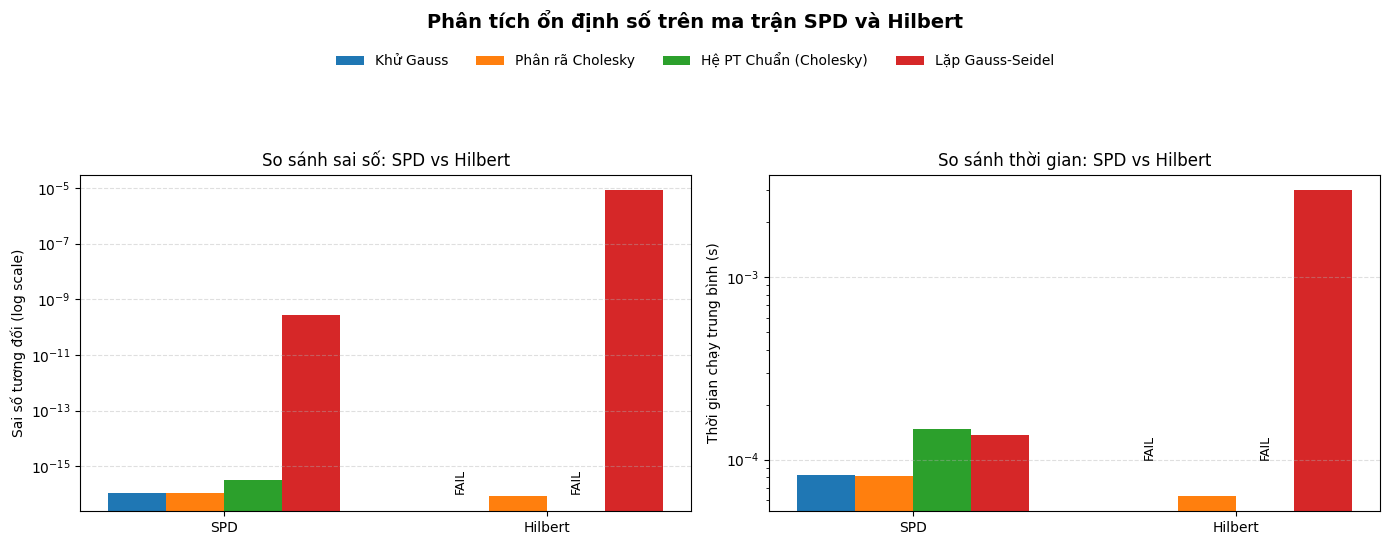

In [ ]:
from benchmark import run_benchmark_stability
import matplotlib.pyplot as plt

# Chạy benchmark stability cho 3 kích thước n
n_list = [10, 20, 50]
stability_results = {}

for n in n_list:
    stability_results[n] = run_benchmark_stability(verbose=False, n=n, num_runs=5)

matrix_types = ['SPD', 'Hilbert']
methods = ['Khu Gauss', 'Phan ra Cholesky', 'He PT Chuan (Cholesky)', 'Lap Gauss-Seidel']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Tổng hợp dữ liệu sai số cho từng phương pháp theo n
errors_by_matrix = {}
for matrix_type in matrix_types:
    errors_by_matrix[matrix_type] = {}
    for method in methods:
        errors_by_matrix[matrix_type][method] = []
        for n in n_list:
            metric = stability_results[n][matrix_type][method]
            errors_by_matrix[matrix_type][method].append(
                metric['avg_error'] if metric['avg_error'] is not None else float('nan')
            )

# Vẽ 2 biểu đồ: SPD và Hilbert
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, matrix_type in enumerate(matrix_types):
    ax = axes[idx]
    bar_width = 0.18
    positions = list(range(len(n_list)))
    
    for method_idx, method in enumerate(methods):
        x_positions = [p + (method_idx - 1.5) * bar_width for p in positions]
        errors = errors_by_matrix[matrix_type][method]
        
        bars = ax.bar(x_positions, errors, width=bar_width, label=method, color=colors[method_idx])
        
        # Đánh dấu các giá trị "FAIL" (NaN)
        for x_pos, value in zip(x_positions, errors):
            if value != value:  # NaN check
                ax.text(x_pos, 1e-17, 'X', ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')
    
    ax.set_xticks(positions)
    ax.set_xticklabels([str(n) for n in n_list])
    ax.set_yscale('log')
    ax.set_ylabel('Sai số tương đối (log scale)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Kích thước ma trận n', fontsize=11, fontweight='bold')
    ax.set_title(f'Sai số: {matrix_type}', fontsize=12, fontweight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=True, bbox_to_anchor=(0.5, 1.02), fontsize=10)
fig.suptitle('Phân tích sai số số học: SPD vs Hilbert theo kích thước n', fontsize=13, fontweight='bold', y=1.08)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


# **KẾT LUẬN CHUNG VỀ PHÂN TÍCH HIỆU SUẤT VÀ ỔN ĐỊNH SỐ**

## **1. Tóm tắt kết quả chính**

### **A. Hiệu suất trên ma trận ngẫu nhiên (n = 50, 100, 200, 500, 1000)**

- **Khử Gauss** là phương pháp chính xác nhất (sai số $\approx 10^{-15}$) nhưng tốc độ tăng theo $O(n^3)$: từ 0.003s (n=50) đến 23.4s (n=1000).

- **Hệ PT Chuẩn (Cholesky)** cho sai số tương tự nhưng chậm hơn nhiều (82s tại n=1000) do bước tính toán ma trận trung gian.

- **Lặp Gauss-Seidel** là **nhanh nhất** (0.25s tại n=1000) nhưng sai số thấp hơn ~7 bậc (khoảng $10^{-9}$). Đây là lựa chọn khi ưu tiên tốc độ.

- **Phân rã Cholesky thất bại hoàn toàn** trên ma trận ngẫu nhiên (không đối xứng, không xác định dương).

### **B. Ổn định số trên ma trận SPD (n = 10, 20, 50)**

- Tất cả phương pháp trực tiếp đều **rất ổn định** với sai số $\approx 10^{-16}$ đến $10^{-15}$, gần giới hạn chính xác máy.

- SPD là trường hợp "lý tưởng": ma trận tốt điều kiện, không có rủi ro số học lớn.

- Gauss-Seidel vẫn hội tụ nhưng sai số cao hơn (~$10^{-9}$) do bản chất của phương pháp lặp.

### **C. Ổn định số trên ma trận Hilbert (n = 10, 20, 50)**

- **Khử Gauss**: Thất bại ở tất cả n.
- **Hệ PT Chuẩn**: Thất bại ở n ≥ 20.
- **Phân rã Cholesky**: Chỉ sống sót ở n = 10 (sai số $8.5 \times 10^{-17}$), thất bại từ n = 20 trở lên.
- **Gauss-Seidel**: **Duy nhất thành công** nhưng sai số tăng theo n: từ $8.35 \times 10^{-6}$ (n=10) → $1.71 \times 10^{-5}$ (n=20) → $2.81 \times 10^{-5}$ (n=50).

## **2. Những phát hiện quan trọng**

### **2.1. Sự ảnh hưởng của điều kiện ma trận**

Ma trận SPD (well-conditioned) và Hilbert (ill-conditioned) cho thấy **chất lượng ma trận quyết định sự thành công của thuật toán**, không phải chỉ lựa chọn phương pháp:
- Trên SPD, mọi phương pháp trực tiếp đều an toàn.
- Trên Hilbert, phương pháp trực tiếp sụp đổ, chỉ phương pháp lặp còn hoạt động.

### **2.2. Sai số trên ma trận ngẫu nhiên vs SPD vs Hilbert**

- **Ma trận ngẫu nhiên** (diagonally dominant): sai số trung bình, tương đối ổn định ($10^{-15}$ đến $10^{-9}$).
- **SPD**: sai số tối ưu, gần giới hạn máy ($10^{-16}$ đến $10^{-15}$).
- **Hilbert**: sai số tệ hoặc không tính được, phương pháp trực tiếp không hoạt động.

### **2.3. Đánh đổi: Tốc độ vs Độ chính xác**

| Phương pháp | Tốc độ (mô hình thực nghiệm) | Độ chính xác (theo benchmark) | Ổn định trên Hilbert |
|---|---|---|---|
| Khử Gauss | $t(n) \approx 3.2\times10^{-3}(n/50)^{2.97}$ s; 23.43s tại n=1000 | Random: $3.29\times10^{-16} \rightarrow 1.61\times10^{-15}$ | **Không** (0/5 ở mọi n) |
| Cholesky | Trên SPD: $t(n) \approx 1.0\times10^{-4}(n/10)^{2.09}$ s; 0.0029s tại n=50 | SPD: $7.26\times10^{-17} \rightarrow 2.08\times10^{-16}$; Hilbert n=10: $8.50\times10^{-17}$ | **Không ổn định** (chỉ chạy được ở n nhỏ) |
| Gauss-Seidel | $t(n) \approx 7.0\times10^{-4}(n/50)^{1.96}$ s; 0.248s tại n=1000 | Random: $1.52\times10^{-9} \rightarrow 1.07\times10^{-8}$; Hilbert: $8.35\times10^{-6} \rightarrow 2.81\times10^{-5}$ | **Có** (thành công ở n=10,20,50) |
| Hệ PT Chuẩn | $t(n) \approx 9.0\times10^{-3}(n/50)^{3.04}$ s; 82.09s tại n=1000 | Random: $2.82\times10^{-16} \rightarrow 9.79\times10^{-16}$; SPD: $4.65\times10^{-16} \rightarrow 2.89\times10^{-15}$ | **Không** (thất bại trên Hilbert) |

## **3. Khuyến nghị thực tế**

### **Khi nào dùng từng phương pháp?**

1. **Khử Gauss**: Lựa chọn "vàng" cho bài toán tổng quát với ma trận dày đặc, well-conditioned. Nhanh, chính xác, dễ cài đặt.

2. **Phân rã Cholesky**: Dành riêng cho ma trận SPD. Nhanh gấp 2 lần Khử Gauss nhưng yêu cầu ma trận phải đảm bảo điều kiện.

3. **Hệ PT Chuẩn**: Hữu ích khi bài toán bội (nhiều vế phải) và ma trận SPD, nhưng thường không xứng với chi phí tính toán trên bài toán đơn.

4. **Gauss-Seidel**: 
   - Khi ma trận quá lớn và chỉ cần lời giải gần đúng nhanh.
   - Khi bài toán ill-conditioned (phương pháp trực tiếp không chạy được).
   - Khi ma trận thưa và tận dụng được cấu trúc (không test trong project này).

### **Những lưu ý khi implement**

- **Luôn kiểm tra điều kiện ma trận**: Compute condition number nếu có thể. Nếu số điều kiện lớn (>$10^6$), hãy cảnh báo người dùng.
- **Xác nhận kết quả**: Luôn kiểm tra sai số tương đối $\|A\hat{x}-b\|_2 / \|b\|_2$ để phát hiện các vấn đề số học.
- **Chọn phương pháp phù hợp với dữ liệu**: Không có "phương pháp tốt nhất" cho tất cả, tùy bối cảnh.

## **4. Kết luận cuối cùng**

Phần phân tích này chứng minh rằng hiệu suất tính toán không chỉ phụ thuộc vào **độ phức tạp thuật toán**, mà còn rất mạnh mẽ phụ thuộc vào **chất lượng bài toán đầu vào**. Một thuật toán có độ phức tạp thấp hơn nhưng không ổn định số trên dữ liệu xấu sẽ không bao giờ tốt bằng một thuật toán ổn định hơn, ngay cả khi nó chậm hơn.

**Khuyến cáo**: Khi triển khai hệ thống tính toán số trong thực tế, hãy luôn kết hợp:
- Phân tích độ phức tạp (Big-O notation)
- Kiểm tra ổn định số (numerical stability testing)
- Xác nhận kết quả với dữ liệu thực tế

Chỉ như vậy, giải pháp mới có thể đáng tin cậy và hiệu quả trên dài hạn.
